In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey!!")
result

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hey!!". Likely greeting. We should respond politely and ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 73, 'total_tokens': 116, 'completion_time': 0.045281976, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.003547361, 'prompt_tokens_details': None, 'queue_time': 0.284858267, 'total_time': 0.048829337}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9a2e-fc62-7630-ad4d-6daccf5235fb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 43, 'total_tokens': 116, 'output_token_details': {'reasoning': 22}})

In [2]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[add,multiply,divide]
tools

[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>]

In [3]:
binded=llm.bind_tools(tools)
binded

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000015DC7C60C50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000015DC745B8D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and

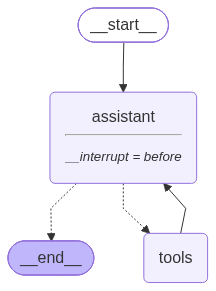

In [4]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
from IPython.display import Image, display

sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

def assistant(state:MessagesState):
    return {"messages":[binded.invoke([sys_msg] + state["messages"])]}

graph=StateGraph(MessagesState)

graph.add_node("assistant",assistant)
graph.add_node("tools",ToolNode(tools))


graph.add_edge(START,"assistant")
graph.add_conditional_edges(
    "assistant",
    tools_condition,

)
graph.add_edge("tools","assistant")

memory=MemorySaver()

build=graph.compile(interrupt_before=["assistant"],checkpointer=memory)

display(Image(build.get_graph().draw_mermaid_png()))

In [5]:
thread={"configurable":{"thread_id":"123"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

In [7]:
for event in build.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [9]:
state=build.get_state(thread)
state.next

('assistant',)

In [10]:
build.get_state_history(thread)

<generator object Pregel.get_state_history at 0x0000015DC810BE20>

In [11]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='dfbe4d26-9878-4e71-a06b-e14dbba6b550')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1885e2-7cad-6fe2-8000-5c998cac1522'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-25T19:22:20.110640+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1885e2-7c9f-646e-bfff-62cfb1eb5524'}}, tasks=(PregelTask(id='3af3928b-9442-bc9f-84f3-dcc9ea2c0260', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [12]:
for event in build.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_00783797-73c6-4394-8eb3-1526d4ecec6f)
 Call ID: fc_00783797-73c6-4394-8eb3-1526d4ecec6f
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [13]:
state=build.get_state(thread)
state.next

('assistant',)

In [14]:
for event in build.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

6
